# 06 — Loss Given Default (LGD) Model

## Objective

In this notebook, we estimate the **Loss Given Default (LGD)**.

Expected Loss (EL) is calculated as:

EL = PD × LGD × EAD

We have already built:
- Probability of Default (PD)
- Population Stability Index (PSI)

Now we estimate LGD.

---

## What is LGD?

Loss Given Default represents the percentage of exposure that the bank loses if a borrower defaults.

LGD = 1 − Recovery Rate

Where:

Recovery Rate = Amount Recovered / Funded Amount

---

## Modeling Strategy

Recovery behavior usually has two characteristics:

1. Many defaults recover **nothing** (Recovery = 0)
2. Some defaults recover **partial amounts**

Because of this structure, we use a **two-stage modeling approach**:

Stage 1: Logistic Regression  
→ Predict probability of recovery > 0

Stage 2: Linear Regression  
→ Predict recovery rate given recovery > 0

Final LGD = 1 − (Stage1 × Stage2)

---

## Why Only Defaulted Loans?

LGD is defined only **conditional on default**.

So we will:
- Filter only defaulted loans
- Build LGD model only on that population


# Step 1 — Preparing Data for LGD

LGD is defined only for defaulted loans.

Therefore, we:
1. Load the cleaned dataset
2. Filter only loans that defaulted
3. Work only on that population

This ensures that we are modeling LGD conditional on default.


In [2]:
import pandas as pd
import numpy as np

# Load cleaned dataset
data = pd.read_csv('../data/processed/credit_data_cleaned_final.csv')

data.columns


Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'MonthlyIncome_missing', 'Dependents_missing',
       'High_Delinquency_Flag', 'DebtRatio_high_flag'],
      dtype='object')

# Step 3 — Constructing a Severity Score

To approximate LGD, we construct a severity score using:

- NumberOfTimes90DaysLate
- High_Delinquency_Flag
- RevolvingUtilizationOfUnsecuredLines

Since these variables are on different scales, we normalize them 
so that each contributes proportionally to the final severity score.

The severity score will then be scaled between 0 and 1 
to serve as an LGD proxy.


In [4]:
# Keep only defaulted loans
lgd_data = data[data['SeriousDlqin2yrs'] == 1].copy()

lgd_data.shape


# Normalize NumberOfTimes90DaysLate
lgd_data['norm_90dpd'] = (
    lgd_data['NumberOfTimes90DaysLate'] - lgd_data['NumberOfTimes90DaysLate'].min()
) / (
    lgd_data['NumberOfTimes90DaysLate'].max() - lgd_data['NumberOfTimes90DaysLate'].min()
)

# Normalize Revolving Utilization
lgd_data['norm_util'] = (
    lgd_data['RevolvingUtilizationOfUnsecuredLines'] - lgd_data['RevolvingUtilizationOfUnsecuredLines'].min()
) / (
    lgd_data['RevolvingUtilizationOfUnsecuredLines'].max() - lgd_data['RevolvingUtilizationOfUnsecuredLines'].min()
)

# High_Delinquency_Flag is already 0/1
lgd_data['norm_flag'] = lgd_data['High_Delinquency_Flag']


## Constructing the Severity Score

We define LGD proxy as a weighted severity score:

LGD severity score =

0.4 × norm_90dpd  
0.4 × norm_util  
0.2 × norm_flag  

Rationale:

- 90+ delinquency frequency strongly reflects repayment distress.
- High revolving utilization indicates financial stress.
- High_Delinquency_Flag captures structural severity.

Weights are chosen heuristically for demonstration purposes.


In [5]:
lgd_data['severity_score'] = (
    0.4 * lgd_data['norm_90dpd'] +
    0.4 * lgd_data['norm_util'] +
    0.2 * lgd_data['norm_flag']
)


In [6]:
lgd_data['severity_score'].describe()


count    10026.000000
mean         0.308096
std          0.180590
min          0.000000
25%          0.169492
50%          0.353750
75%          0.400000
max          1.000000
Name: severity_score, dtype: float64

In [7]:
lgd_data['LGD_proxy'] = lgd_data['severity_score']


In [8]:
lgd_data['LGD_proxy'].describe()


count    10026.000000
mean         0.308096
std          0.180590
min          0.000000
25%          0.169492
50%          0.353750
75%          0.400000
max          1.000000
Name: LGD_proxy, dtype: float64

In [9]:
lgd_data['NumberOfTimes90DaysLate'].describe()


count    10026.000000
mean         0.799721
std          1.684840
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         10.000000
Name: NumberOfTimes90DaysLate, dtype: float64

In [10]:
lgd_data['NumberOfTimes90DaysLate'].value_counts().sort_index().tail(10)


NumberOfTimes90DaysLate
1     1765
2      776
3      385
4      195
5       83
6       48
7       31
8       15
9       14
10     160
Name: count, dtype: int64

In [11]:
lgd_data['NumberOfTimes90DaysLate'].quantile([0.90, 0.95, 0.99, 0.999])


0.900     2.0
0.950     4.0
0.990    10.0
0.999    10.0
Name: NumberOfTimes90DaysLate, dtype: float64

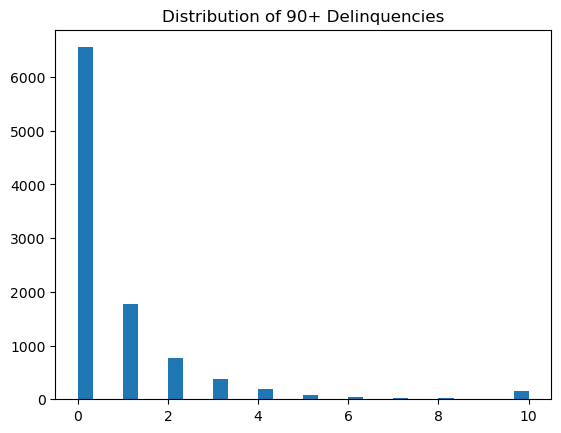

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.hist(lgd_data['NumberOfTimes90DaysLate'], bins=30)
plt.title("Distribution of 90+ Delinquencies")
plt.show()


## Diagnostic Check — Correlation Between Severity Inputs

Before estimating the LGD model, we examine the correlation between:

- norm_90dpd
- norm_util
- norm_flag

Purpose:

- Ensure we are not double-counting severity
- Identify potential redundancy
- Understand structural relationships between inputs

Note:
High correlation (> 0.9) may indicate overlapping signal.
Moderate correlation is acceptable in risk modeling.


In [14]:
# Select severity input variables
severity_inputs = lgd_data[['norm_90dpd', 'norm_util', 'norm_flag']]

# Compute correlation matrix
corr_matrix = severity_inputs.corr()

corr_matrix


,norm_90dpd,norm_util,norm_flag
norm_90dpd,1.000000,0.234920,0.675684
norm_util,0.234920,1.000000,0.108501
norm_flag,0.675684,0.108501,1.000000


## Stage 1 Target Definition

Since actual recovery data is unavailable, we define a proxy binary target:

1 = Structurally Severe Case (Likely High LGD)
0 = Moderate Severity Case (Potential Partial Recovery)

We define severe cases as:

severity_score > 0.5

This threshold is chosen to represent high structural delinquency and financial stress, aligning with business intuition rather than arbitrary selection.


In [15]:
lgd_data['lgd_stage1_target'] = np.where(
    lgd_data['severity_score'] > 0.5,
    1,
    0
)

lgd_data['lgd_stage1_target'].value_counts(normalize=True)


lgd_stage1_target
0    0.928187
1    0.071813
Name: proportion, dtype: float64

## Stage 1 – Logistic Regression (Probability of Severe LGD)

We model the probability that a defaulted exposure is structurally severe 
(using lgd_stage1_target).

Inputs:
- norm_90dpd
- norm_util
- norm_flag

These normalized variables ensure balanced contribution and stable estimation.


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

# Define inputs and target
X_stage1 = lgd_data[['norm_90dpd', 'norm_util', 'norm_flag']]
y_stage1 = lgd_data['lgd_stage1_target']

# Split data
X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(
    X_stage1, y_stage1, test_size=0.2, random_state=42
)

# Train logistic model
log_reg_s1 = LogisticRegression(max_iter=1000)
log_reg_s1.fit(X_train_s1, y_train_s1)

print("Stage 1 model trained successfully.")


Stage 1 model trained successfully.


In [17]:
y_pred_proba_s1 = log_reg_s1.predict_proba(X_test_s1)[:, 1]

auc_s1 = roc_auc_score(y_test_s1, y_pred_proba_s1)
print("Stage 1 AUC:", round(auc_s1, 4))


Stage 1 AUC: 0.9996


### Initial Attempt (Discarded Due to Target Leakage)


## Stage 1 – Revised Model (Leakage-Free)

To avoid deterministic leakage, we exclude severity construction variables 
(NumberOfTimes90DaysLate, High_Delinquency_Flag, and derived normalized features).

Instead, we use borrower financial and structural characteristics:

- age
- DebtRatio
- MonthlyIncome
- RevolvingUtilizationOfUnsecuredLines
- NumberOfOpenCreditLinesAndLoans

These variables represent borrower financial profile rather than recovery mechanics.
